# Savings rate

There's a simple analysis available at https://www.mrmoneymustache.com/2012/01/13/the-shockingly-simple-math-behind-early-retirement/ .  This document more or less replicates that analysis, while highlighting the assumptions along the way.

## Imports

In [20]:
import math
import matplotlib.pyplot as pyplot

## Problem statement

If your current expenses and income remain flat in real terms (i.e., grow commensurate with inflation), and you invest all of your savings (income - expenses) into an investment portfolio with a known return, then how long must you save until your portfolio fully covers your expenses?

### Assumptions

There are numerous assumptions needed to make this a textbook calculation, which may or may not be all that realistic.  Nevertheless, this is the starting point of the anaylsis.

- income and expenses remain constant in real terms during the savings period, and expenses remain constant during retirement
- all savings go into the investment porfolio, and are never withdrawn during the savings period
- all quantities (income, expenses, savings) are distributed at the same time monthly
- the investment portfolio provides a constant, real rate of return
- the investment portfolio supports a safe withdrawal rate at any time during the analysis, however defined

### Units

The only absolute scale in the problem is set by either the income, savings, or expenses rate.  As a matter of choice, I'm using the reference quantity as the monthly income.

## Portfolio growth with monthly compounding

Given a known investment rate of return, we can convert this to a monthly rate of compounding.  For example, if $r_y$ is the investment rate of return assuming yearly compunding, then rate of return with monthly compounding $r_m$ is found via  
$r_m = 12 \left[ \left( 1 + r_y \right)^{1 / 12} - 1 \right] \quad .$  

Given the monthly savings rate $s_m$, the value of the investment portfolio after $n \ge 1$ months of compounding, $P_n$, is given by  
$P_n = s_m \sum_{j = 1}^n \left( 1 + \frac{r_m}{12} \right)^j \quad .$  
This is a geometric series, which can be evaluated as   
##### $P_n = \frac{s_m}{\left( r_m / 12 \right)}\left( 1 + \frac{r_m}{12} \right) \left[ \left( 1 + \frac{r_m}{12} \right)^n - 1 \right] \quad . $  

## Calculating the months to retirement

Given the investment portfolio value $P_n$ after $n$ months of saving, we can evaluate when investment returns will sustain expenses using the safe withdrawal rate $r_w$.  This is typically understood as a yearly withdrawal rate, e.g. as stated in "the 4% rule," but for convenience I'm considering a safe **monthly** withdrawal rate.  My understanding is that the yearly safe withdrawal rate results from volatility moreso than yearly returns, so I actually suspect that the monthly safe withdrawal rate might be less than the yearly analog.  Nevertheless, I'm going to make the simplifying assumption that they're related by just divinding by 12.  I.e., if 4% is the yearly "safe withdrawal rate," then $r_w$ for the purpose of the current calculation is (4 / 12)%, or 1/3%.

The rate of expenses is known from the savings rate, as the two must add up to the monthly income.  Since the monthly income is the only scale in the problem, we can consider dimensionless rates of spending $s_m$ and expenses $E_m$, so that  
$E_m = 1 - s_m \quad .$  
Then, the investment portfolio $P_n$ after $n$ months of saving can satisfy the current level of expenses once the monthly safe withdrawal rate $r_w$ exceeds the expense rate $1 - s_m$, or  
$ 1 - s_m \le r_w P_n = \frac{r_w s_m}{\left( r_m / 12 \right)}\left( 1 + \frac{r_m}{12} \right) \left[ \left( 1 + \frac{r_m}{12} \right)^n - 1 \right] \quad .$  
Keeping in mind that the number of months $n$ is discrete in this calculation, as we're explicitly considering monthly compounding and not continuous compounding, the first $n$ that exceeds this threshold is the number of months of savings required to sustain expenses from the investment portfolio.  In other words, we can solve the above expression for $n$ so long as we restrict ourselves to the ceiling, rather than attempting to interpolate between integral months.  I.e., the number of months to save $n$, given the monthly savings rate $s_m$, the monthly safe withdrawal rate $r_w$, and the monthly real investment rate of return $r_m$, is given by:  
### $n = \lceil \frac{\ln \left[ 1 + \frac{(r_m / 12)}{1 + (r_m / 12)} \frac{1 - s_m}{r_w s_m} \right]}{\ln \left( 1 + \frac{r_m}{12} \right)} \rceil \quad .$  

## Function definitions

The only absolute scale in the problem is set by either the income, savings, or expenses rate.  As a matter of choice, I'm using the reference quantity as the monthly income.

In [3]:
def monthly_rate_from_yearly_rate(yearly_rate: float) -> float:
    """
    Convert a yearly compounding rate to a monthly compounding rate.
    - yearly_rate: the yearly compounding rate.  E.g., 8% yearly compounding has a yearly_rate=0.08.
    """
    return 12 * (math.pow(1 + yearly_rate, 1 / 12) - 1)

def months_to_retirement(savings_ratio: float, yearly_real_investment_rate: float, yearly_safe_withdrawal_rate: float) -> int:
    """
    Calculates the months to retirement based on the input parameters and constant expenses in real terms.
    """
    monthly_withdrawal_rate = yearly_safe_withdrawal_rate / 12  # Simplifying assumption
    monthly_investment_rate = monthly_rate_from_yearly_rate(yearly_real_investment_rate)
    rate_12 = monthly_investment_rate / 12
    numerator = math.log(
        1 + ((rate_12) / (1 + rate_12)) * (1 - savings_ratio) / (monthly_withdrawal_rate * savings_ratio)
        )
    denominator = math.log(1 + rate_12)
    return math.ceil(numerator / denominator)

### Benchmark comparison

Below uses values seen in the reference article https://www.mrmoneymustache.com/2012/01/13/the-shockingly-simple-math-behind-early-retirement/ .

In [ ]:
savings_ratio = 0.1
yearly_real_investment_return = 0.05
yearly_safe_withdrawal_rate = 0.04

months = months_to_retirement(
    savings_ratio, yearly_real_investment_return, yearly_safe_withdrawal_rate
    )

# The link seems to round up by year, or to the nearest half-year
years = months // 12
print(f"{years} years and {months - (12 * years)} months to retirement")

50 years and 11 months to retirement


## Calculating the savings rate for a target retirement date

Similarly to the previous calculation, we could ask the inverse question: _What is the required savings rate needed to retire in a set number of months in the future?_  We can start with the same expression as before, but solve for $s_m$ instead of $n$; i.e.,  
$\ldots$  

## Plots of various savings rates and times to retirement

## Global plotting parameters

In [22]:
pyplot.rcParams["figure.figsize"] = (15,5)
pyplot.style.use('dark_background')

### Base comparison

The plot below considers the values from the reference article https://www.mrmoneymustache.com/2012/01/13/the-shockingly-simple-math-behind-early-retirement/, or:
- 4% safe yearly withdrawal rate (converted internally to 1/3% monthly safe withdrawal rate)
- 5% yearly real investment returns for saved contributions

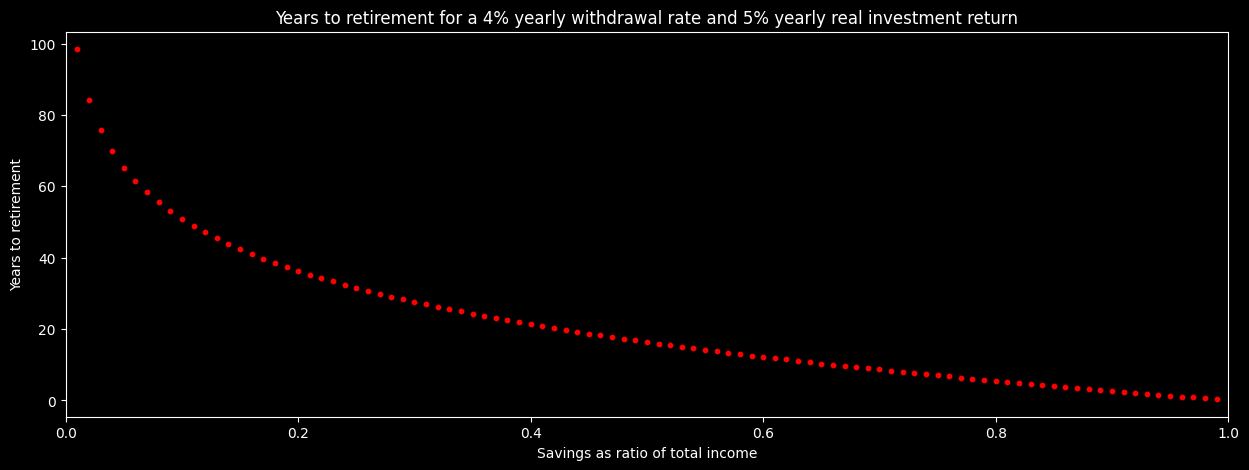

In [38]:
yearly_real_investment_return = 0.05
yearly_safe_withdrawal_rate = 0.04

savings_rates = [
    0.01 * step for step in range(1, 100)
]
years_by_rate = [
    months_to_retirement(savings_rate, yearly_real_investment_return, yearly_safe_withdrawal_rate) / 12
    for savings_rate in savings_rates
]

pyplot.scatter(x=savings_rates, y=years_by_rate, s=10, color='red')
pyplot.xlabel('Savings as ratio of total income')
pyplot.ylabel('Years to retirement')
pyplot.xlim(0, 1)
pyplot.title('Years to retirement for a 4% yearly withdrawal rate and 5% yearly real investment return')
pyplot.show()